# Topic and Theme Analysis
This notebook analyzes the papers from the hEART 2026 conference based on the generated `papers.json` file.

In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load the paper data
with open('public/data/papers.json', 'r') as f:
    data = json.load(f)

papers = data['papers']
df = pd.DataFrame(papers)
print(f"Loaded {len(df)} papers.")
df.head()

Loaded 232 papers.


,id,title,authors,presenter,abstract,keywords,date,time,sessionInterval,session,track,room,type,url,most_similar_ids,most_similar_scores,x,y
0,320869,To share or not to share? A Sequential SEM Ana...,"[Sarah Stelter, Sonja Haustein, Felix Wilhelm ...",Sarah Stelter,"Cooperative, Connected and Autonomous Mobility...","[Autonomous mobility, Behavioural Intention, C...",2026-09-29,10:15,10:15-12:45,"Session 8A: [Podium] Demand modelling, accessi...","Demand modelling, accessibility & activity pat...",Auditorium,Podium,https://easychair.org/smart-program/hEART2026/...,"[320889, 320854, 320780, 320901, 320997]","[0.19407820409607085, 0.11135673722488718, 0.0...",17.83,85.84
1,320974,Follow the e-riders: Exploring behaviour chang...,"[Alfredo Jose Ojeda Diaz, Emma-Sofie Hestbech,...",Alfredo Jose Ojeda Diaz,Promotion and assessment of sustainable and ac...,"[Cycling behaviour, electric bikes, longitudin...",2026-09-29,10:45,10:15-12:45,"Session 8A: [Podium] Demand modelling, accessi...","Demand modelling, accessibility & activity pat...",Auditorium,Podium,https://easychair.org/smart-program/hEART2026/...,"[320997, 321000, 320780, 320901, 320804]","[0.22078207051116275, 0.13795872376066576, 0.1...",10.83,83.85
2,320875,Analysing modal shift and induced demand for i...,"[Behzad Bamdad Mehrabani, Willem Himpe, Juan B...",Behzad Bamdad Mehrabani,Innovative Air Mobility (IAM) is expected to e...,"[Demand Modelling, discrete choice modelling, ...",2026-09-29,11:15,10:15-12:45,"Session 8A: [Podium] Demand modelling, accessi...","Demand modelling, accessibility & activity pat...",Auditorium,Podium,https://easychair.org/smart-program/hEART2026/...,"[320854, 320882, 320784, 320792, 320948]","[0.09185661817109607, 0.0858645259495228, 0.08...",24.45,64.53
3,320776,Effects of Road and Other Mode Supply on Car Use,"[Maria Borjesson, Pernilla Ivehammar]",Maria Borjesson,This paper estimates how changes in road suppl...,"[Logsum, Non-car transport modes, Panel data, ...",2026-09-29,11:45,10:15-12:45,"Session 8A: [Podium] Demand modelling, accessi...","Demand modelling, accessibility & activity pat...",Auditorium,Podium,https://easychair.org/smart-program/hEART2026/...,"[320857, 321002, 320785, 320951, 320935]","[0.09564177253543153, 0.08563124125649853, 0.0...",24.20,62.93
4,320855,Perceived Mobility Need Satisfaction across Tr...,"[Stefan Bohmann, Eva Maria Kastl, Anja Kathari...",Stefan Bohmann,This study provides a first psychometric exami...,"[Confirmatory factor analysis, Mobility behavi...",2026-09-29,12:15,10:15-12:45,"Session 8A: [Podium] Demand modelling, accessi...","Demand modelling, accessibility & activity pat...",Auditorium,Podium,https://easychair.org/smart-program/hEART2026/...,"[320844, 320889, 320932, 320936, 320946]","[0.11587410740183836, 0.09575470474417393, 0.0...",13.05,67.92


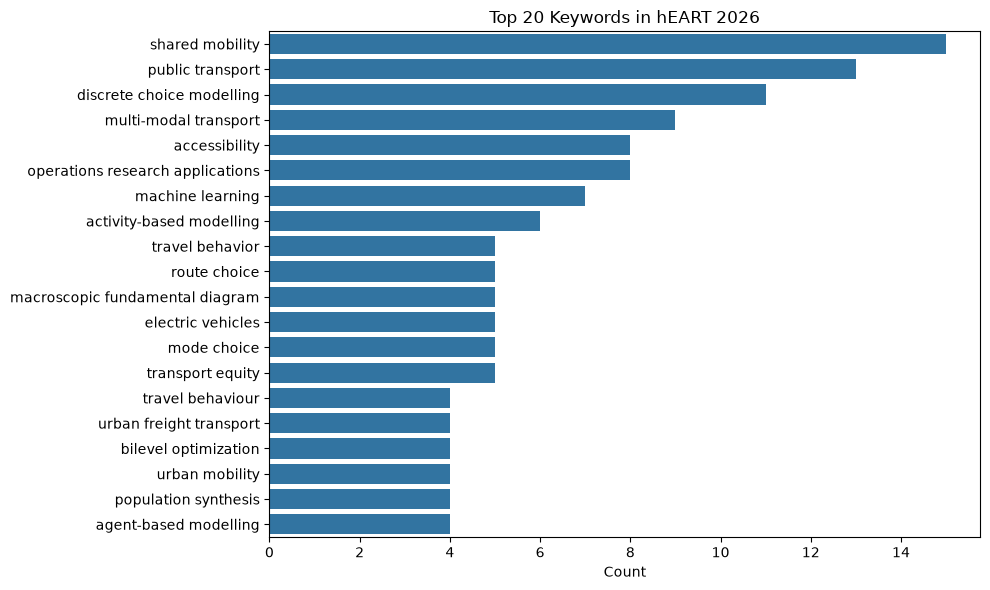

In [3]:
# 1. Explore Keywords and Themes
all_keywords = [kw.lower() for keywords in df['keywords'] for kw in keywords]
keyword_counts = Counter(all_keywords)

# Plot top 20 keywords
top_kws = keyword_counts.most_common(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=[x[1] for x in top_kws], y=[x[0] for x in top_kws])
plt.title('Top 20 Keywords in hEART 2026')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

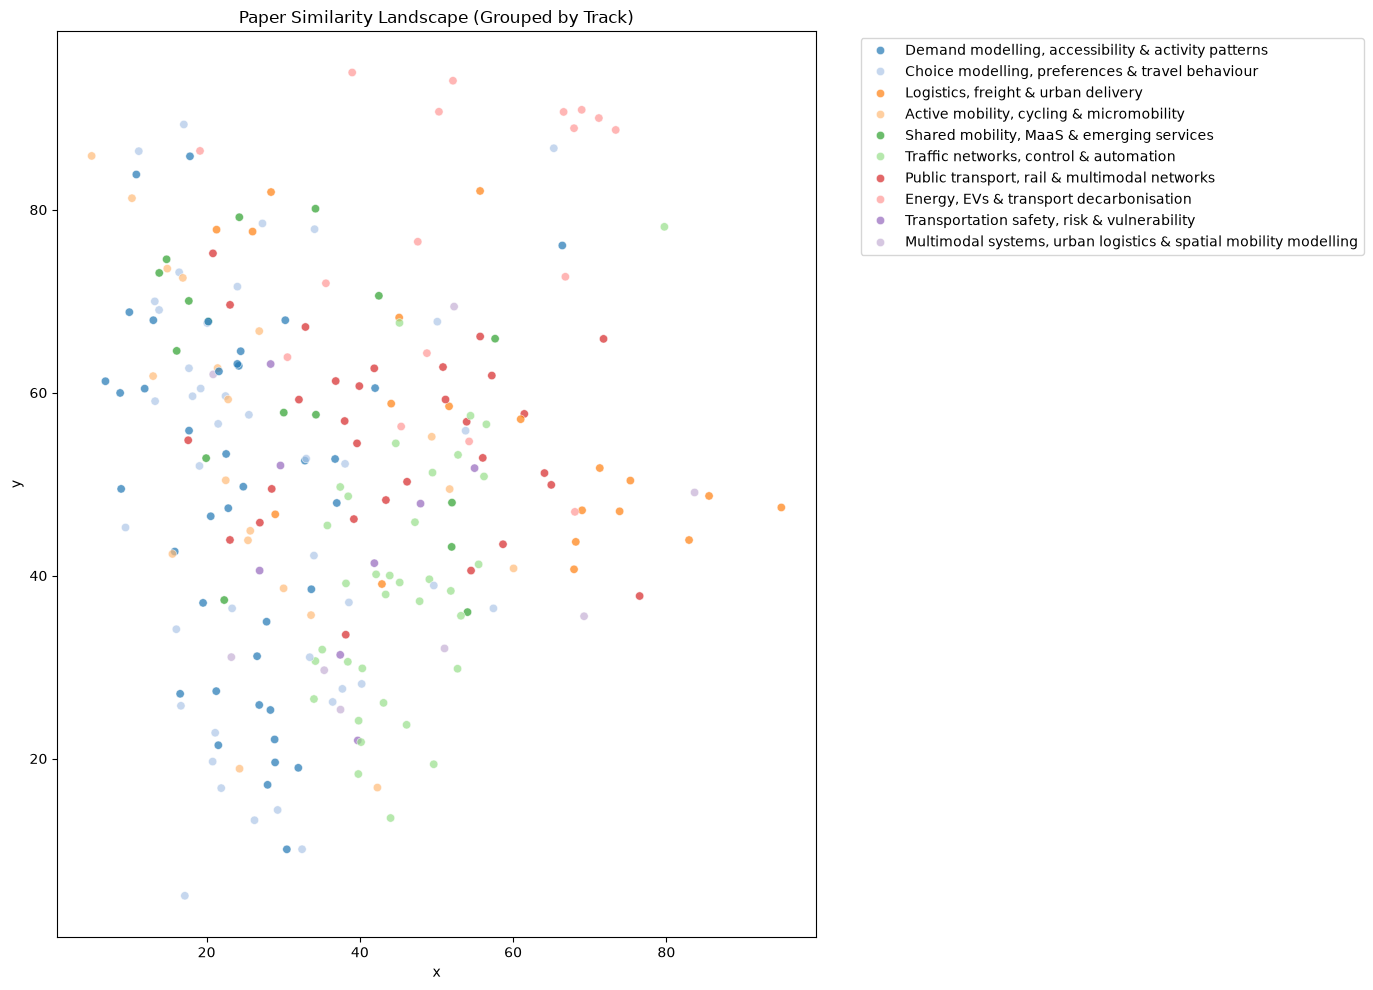

In [4]:
# 2. Exploring Topic Similarity Clusters
# The similarity script generates 'x' and 'y' coordinates using Eigenvectors.
# We can plot these to see how topics group together visually.
plt.figure(figsize=(14, 10))
sns.scatterplot(data=df, x='x', y='y', hue='track', alpha=0.7, palette='tab20')
plt.title('Paper Similarity Landscape (Grouped by Track)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [6]:

_title ='A Stochastic Assessment of Hydrogen’s Potential in Decarbonizing Road Transport'
df[df['title']==_title]

,id,title,authors,presenter,abstract,keywords,date,time,sessionInterval,session,track,room,type,url,most_similar_ids,most_similar_scores,x,y
228,320817,A Stochastic Assessment of Hydrogen’s Potentia...,"[Matilde Gasparetto, Federico Cavallaro, Silvi...",Matilde Gasparetto,The decarbonisation of long-distance freight t...,"[Freight transport, Hydrogen mobility, Monte C...",2026-10-01,,14:00-16:00,"Session 21E: [Poster] Energy, EVs & transport ...","Energy, EVs & transport decarbonisation",La salle 116,Poster,https://easychair.org/smart-program/hEART2026/...,"[320877, 320962, 320829, 320779, 320852]","[0.14229153547932977, 0.10575305731450042, 0.1...",45.39,56.3


In [5]:
# 3. Analyzing "Most Similar" Papers
# Let's look at a specific paper and see its closest neighbors based on your new weights
if 'most_similar_ids' in df.columns:
    sample_paper = df.iloc[228]
    
    print(f"Target Paper: {sample_paper['title']} (Track: {sample_paper['track']})\n")
    
    print("Most Similar Papers:")
    for sim_id, score in zip(sample_paper['most_similar_ids'], sample_paper['most_similar_scores']):
        match = df[df['id'] == sim_id]
        if not match.empty:
            print(f"- [Score: {score:.3f}] - track: {match.iloc[0]['track']} -> {match.iloc[0]['title']} ")


Target Paper: A Stochastic Assessment of Hydrogen’s Potential in Decarbonizing Road Transport (Track: Energy, EVs & transport decarbonisation)

Most Similar Papers:
- [Score: 0.142] - track: Logistics, freight & urban delivery -> From technology comparison to corridor allocation: modelling charging alternatives for battery-electric freight vehicles 
- [Score: 0.106] - track: Logistics, freight & urban delivery -> A Systematic Framework for Risk-Aware UAV Cargo Corridor Design 
- [Score: 0.105] - track: Logistics, freight & urban delivery -> A Container Truck Appointment Scheduling Problem Considering Hydrogen Refueling and Soft Time Windows 
- [Score: 0.093] - track: Choice modelling, preferences & travel behaviour -> Bayesian Deep Learning for Discrete Choice 
- [Score: 0.081] - track: Multimodal systems, urban logistics & spatial mobility modelling -> Graph neural network-guided optimization for intermodal transport planning under uncertainty 


In [11]:
!python scripts/build_paper_data.py data/raw/heart29.html data/raw/heart30.html data/raw/heart01.html --keywords data/raw/heart_keywords.html

Wrote 231 papers to public/data/papers.json
